In [ ]:
# Install required libraries
!pip install -q ultralytics kagglehub opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 45.7 MB/s eta 0:00:00


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mksaad/wider-face-a-face-detection-benchmark")

print("Path to dataset files:", path)

100%|██████████| 3.41G/3.41G [00:38<00:00, 95.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mksaad/wider-face-a-face-detection-benchmark/versions/4


In [ ]:
import os
import shutil
import cv2
from ultralytics import YOLO

# === Paths ===
ANNOTATION_DIR = "/root/.cache/kagglehub/datasets/mksaad/wider-face-a-face-detection-benchmark/versions/4/wider_face_split/wider_face_split"
TRAIN_IMG_DIR = "/root/.cache/kagglehub/datasets/mksaad/wider-face-a-face-detection-benchmark/versions/4/WIDER_train/WIDER_train/images"
VAL_IMG_DIR = "/root/.cache/kagglehub/datasets/mksaad/wider-face-a-face-detection-benchmark/versions/4/WIDER_val/WIDER_val/images"

TRAIN_ANNOTATION_FILE = os.path.join(ANNOTATION_DIR, "wider_face_train_bbx_gt.txt")
VAL_ANNOTATION_FILE = os.path.join(ANNOTATION_DIR, "wider_face_val_bbx_gt.txt")

YOLO_DATASET_DIR = "dataset"

# === Create YOLO directory structure ===
for split in ['train', 'val']:
    os.makedirs(os.path.join(YOLO_DATASET_DIR, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DATASET_DIR, 'labels', split), exist_ok=True)

# === Annotation conversion function ===
def convert_widerface_to_yolo(txt_path, image_root, split):
    with open(txt_path, 'r') as f:
        lines = f.readlines()

    idx = 0
    while idx < len(lines):
        rel_image_path = lines[idx].strip()
        face_count = int(lines[idx + 1].strip())
        full_image_path = os.path.join(image_root, rel_image_path)

        # Validate image
        if not os.path.exists(full_image_path):
            print(f" Image not found: {full_image_path}")
            idx += 2 + face_count
            continue

        img = cv2.imread(full_image_path)
        if img is None:
            print(f" Failed to read image: {full_image_path}")
            idx += 2 + face_count
            continue

        h, w = img.shape[:2]
        labels = []

        for i in range(face_count):
            x, y, bw, bh = map(int, lines[idx + 2 + i].strip().split()[:4])
            cx = (x + bw / 2) / w
            cy = (y + bh / 2) / h
            nw = bw / w
            nh = bh / h
            labels.append(f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        # Save label file
        image_name = os.path.basename(rel_image_path)
        label_file = os.path.join(YOLO_DATASET_DIR, 'labels', split, image_name.replace(".jpg", ".txt"))
        with open(label_file, 'w') as f_out:
            f_out.write('\n'.join(labels))

        # Copy image to YOLO image folder
        shutil.copy(full_image_path, os.path.join(YOLO_DATASET_DIR, 'images', split, image_name))

        idx += 2 + face_count

# === Run conversion ===
convert_widerface_to_yolo(TRAIN_ANNOTATION_FILE, TRAIN_IMG_DIR, "train")
convert_widerface_to_yolo(VAL_ANNOTATION_FILE, VAL_IMG_DIR, "val")
print(" Annotations converted to YOLO format!")

# === Create data.yaml file ===
with open("widerface.yaml", "w") as f:
    f.write(
        "path: dataset\n"
        "train: images/train\n"
        "val: images/val\n"
        "names:\n"
        "  0: face\n"
    )
print(" widerface.yaml created!")




 Annotations converted to YOLO format!
 widerface.yaml created!


In [ ]:
# === Train the model ===
model = YOLO("yolov8n.pt")  # Change to yolov8s.pt or yolov8m.pt if needed
model.train(data="widerface.yaml", epochs=30, imgsz=640, batch=16)
metrics = model.val()  # Uses validation set from data.yaml

In [ ]:
# Correct: Access attributes, do NOT call them as functions
print(f" mAP@0.5: {metrics.box.map50:.4f}")
print(f" mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f" Precision (mean): {metrics.box.mp:.4f}")
print(f" Recall (mean): {metrics.box.mr:.4f}")
print(f" Inference Speed: {metrics.speed['inference']:.2f} ms/image")
fps = 1000 / metrics.speed['inference']
print(f" FPS: {fps:.2f} frames per second")

 mAP@0.5: 0.6246
 mAP@0.5:0.95: 0.3383
 Precision (mean): 0.8260
 Recall (mean): 0.5445
 Inference Speed: 207.69 ms/image
 FPS: 4.81 frames per second



image 1/1 /content/dataset/images/val/0_Parade_Parade_0_376.jpg: 448x640 9 faces, 244.2ms
Speed: 8.6ms preprocess, 244.2ms inference, 2.8ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs/detect/predict


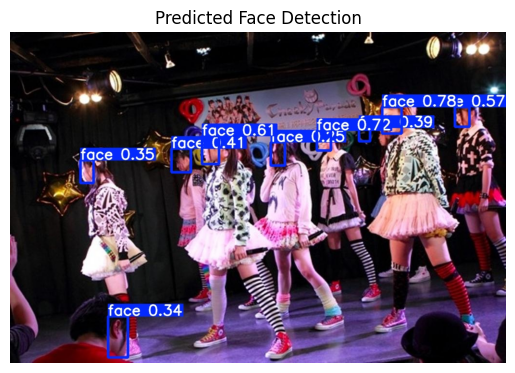

In [ ]:
import cv2
import matplotlib.pyplot as plt

results = model.predict(source="/content/dataset/images/val/0_Parade_Parade_0_376.jpg", conf=0.25, save=True)
img = cv2.imread("runs/detect/predict/0_Parade_Parade_0_376.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')
plt.title("Predicted Face Detection")
plt.show()

